In [ ]:
# Análisis de datos externos para ampliar la base de IA

Este notebook:
1. revisa el formato del dataset público;
2. detecta si las matrices vienen como ROI x frames o frames x ROI;
3. las convierte a un formato estándar por frame y por ROI;
4. extrae características por ROI y por día;
5. aplica clustering y compara si aparecen patrones similares a los del análisis interno.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

try:
    import umap
except Exception:
    umap = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

BASE_DIR = Path(r'c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo')
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'salidas'
OUTPUT_DIR.mkdir(exist_ok=True)


def decode_hdf5_text(value):
    arr = np.array(value).squeeze()
    if arr.dtype.kind in {'u', 'i'}:
        return ''.join(chr(int(v)) for v in arr if int(v) != 0).strip()
    if arr.dtype.kind == 'S':
        joined = b''.join(np.atleast_1d(arr).astype('S'))
        return joined.decode('utf-8', errors='ignore').strip()
    if arr.shape == ():
        item = arr.item()
        if isinstance(item, (bytes, bytearray)):
            return item.decode('utf-8', errors='ignore').strip()
        return str(item).strip()
    return str(arr).strip()


def load_external_mat(mat_path):
    with h5py.File(mat_path, 'r') as handle:
        group = handle['data']
        activity_dff = np.array(group['activity_dff'], dtype=float)
        activity_decon = np.array(group['activity_decon'], dtype=float)
        spontaneous_decon = np.array(group['spontaneous_decon'], dtype=float)
        stim_vec = np.array(group['stim_vec'], dtype=float).squeeze()
        meta_group = group['meta']

        meta = {}
        for key in meta_group.keys():
            if key == 'roi':
                continue
            meta[key] = decode_hdf5_text(meta_group[key][()])

        meta['roi_x'] = np.array(meta_group['roi']['X'], dtype=float).squeeze()
        meta['roi_y'] = np.array(meta_group['roi']['Y'], dtype=float).squeeze()

    return {
        'activity_dff': activity_dff,
        'activity_decon': activity_decon,
        'spontaneous_decon': spontaneous_decon,
        'stim_vec': stim_vec,
        'meta': meta,
    }


def to_standard_wide(activity_dff):
    n_frames, n_rois = activity_dff.shape
    wide = pd.DataFrame(activity_dff, columns=[f'ROI{i+1}' for i in range(n_rois)])
    wide.insert(0, 'Frame', np.arange(1, n_frames + 1))
    return wide


def contiguous_segments(mask):
    segments = []
    start = None
    for idx, flag in enumerate(mask):
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            segments.append((start, idx - 1))
            start = None
    if start is not None:
        segments.append((start, len(mask) - 1))
    return segments


def extract_trace_features(trace, smooth_window=7, baseline_fraction=0.15, threshold_factor=2.5, min_event_frames=3):
    trace = np.asarray(trace, dtype=float)
    trace = trace[np.isfinite(trace)]
    if trace.size == 0:
        return {
            'mean_signal': np.nan,
            'std_signal': np.nan,
            'min_signal': np.nan,
            'max_signal': np.nan,
            'baseline_center': np.nan,
            'threshold': np.nan,
            'n_events': 0,
            'mean_event_duration': np.nan,
            'max_event_duration': np.nan,
            'mean_event_amplitude': np.nan,
            'max_event_amplitude': np.nan,
            'auc_above_baseline': np.nan,
            'peak_frame': np.nan,
            'peak_value': np.nan,
            'global_slope': np.nan,
        }

    smooth = pd.Series(trace).rolling(smooth_window, center=True, min_periods=1).mean().to_numpy()
    baseline_n = max(20, int(len(smooth) * baseline_fraction))
    baseline = smooth[:baseline_n]
    baseline_center = float(np.nanmedian(baseline))
    mad = float(np.nanmedian(np.abs(baseline - baseline_center)))
    spread = 1.4826 * mad
    if not np.isfinite(spread) or spread == 0:
        spread = float(np.nanstd(baseline))
    if not np.isfinite(spread) or spread == 0:
        spread = 1e-9

    threshold = baseline_center + threshold_factor * spread
    above = smooth > threshold
    segments = [seg for seg in contiguous_segments(above) if (seg[1] - seg[0] + 1) >= min_event_frames]
    event_durations = [end - start + 1 for start, end in segments]
    event_peaks = [float(np.nanmax(smooth[start:end + 1])) for start, end in segments] if segments else []
    event_amplitudes = [peak - baseline_center for peak in event_peaks] if event_peaks else []
    peak_idx = int(np.nanargmax(smooth))
    peak_value = float(smooth[peak_idx])
    auc_above = float(np.nansum(np.clip(smooth - baseline_center, 0, None)))
    slope = float(np.polyfit(np.arange(len(smooth)), smooth, 1)[0]) if len(smooth) >= 2 else np.nan

    return {
        'mean_signal': float(np.nanmean(smooth)),
        'std_signal': float(np.nanstd(smooth)),
        'min_signal': float(np.nanmin(smooth)),
        'max_signal': float(np.nanmax(smooth)),
        'baseline_center': baseline_center,
        'threshold': threshold,
        'n_events': int(len(segments)),
        'mean_event_duration': float(np.nanmean(event_durations)) if event_durations else np.nan,
        'max_event_duration': float(np.nanmax(event_durations)) if event_durations else np.nan,
        'mean_event_amplitude': float(np.nanmean(event_amplitudes)) if event_amplitudes else np.nan,
        'max_event_amplitude': float(np.nanmax(event_amplitudes)) if event_amplitudes else np.nan,
        'auc_above_baseline': auc_above,
        'peak_frame': int(peak_idx + 1),
        'peak_value': peak_value,
        'global_slope': slope,
    }


def resolve_sample_path(row, day_token):
    return DATA_DIR / row['condition'] / row['mouse'] / row['FOV'] / f'data_{day_token}.mat'


def layout_label(activity_dff, meta):
    n_rois = len(np.atleast_1d(meta.get('roi_x', [])))
    if activity_dff.shape[1] == n_rois:
        return 'frames x rois'
    if activity_dff.shape[0] == n_rois:
        return 'rois x frames'
    return 'unknown'


c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Inspección del formato del dataset externo
manifest = pd.read_csv(DATA_DIR / 'overview_all.csv')
manifest['available_days_list'] = manifest['available_days'].fillna('').apply(lambda text: [day.strip() for day in str(text).split(',') if day.strip()])

print('Filas del manifest:', len(manifest))
print(manifest.head().to_string(index=False))

first_row = manifest.iloc[0].to_dict()
first_day = first_row['available_days_list'][0]
first_sample_path = resolve_sample_path(first_row, first_day)
print('\nEjemplo de archivo:', first_sample_path)

sample = load_external_mat(first_sample_path)
activity = sample['activity_dff']
meta = sample['meta']
label = layout_label(activity, meta)

print('Metadatos decodificados:')
print({k: meta[k] for k in ['condition', 'mouse', 'day', 'date', 'sampling_freq', 'zdepth'] if k in meta})
print('Forma activity_dff:', activity.shape)
print('Etiqueta de orientación:', label)
print('Número de ROI en metadata:', len(np.atleast_1d(meta['roi_x'])))
print('Número de frames inferido:', activity.shape[0])
print('Número de ROI inferido:', activity.shape[1])

standard_preview = to_standard_wide(activity)
print('\nVista estándar de ejemplo (primeras 6 filas y 8 columnas):')
print(standard_preview.iloc[:6, :8].to_string(index=False))

preview_path = OUTPUT_DIR / 'sample_standard_preview.csv'
standard_preview.iloc[:50, :12].to_csv(preview_path, index=False)
print('Vista previa guardada en:', preview_path)


Filas del manifest: 323
condition mouse        FOV             available_days                 available_days_list
      inh  U411 Reg03_z123 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z147 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z167 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z198 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z223 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]

Ejemplo de archivo: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\data\inh\U411\Reg03_z123\data_d1.mat
Metadatos decodificados:
{'condition': 'inh', 'mouse': 'U411', 'day': 'd1', 'date': '200216', 'sampling_freq': '5.0', 'zdepth': '123.0'}
Forma activity_dff: (2088, 382)
Etiqueta de orientación: frames x rois
Número de ROI en metadata: 382
Número de frames inferido: 2088
Número de ROI inferido: 382

Vista 

In [7]:
manifest = pd.read_csv(DATA_DIR / 'overview_all.csv')
manifest['available_days_list'] = manifest['available_days'].fillna('').apply(lambda text: [day.strip() for day in str(text).split(',') if day.strip()])

print('Filas del manifest:', len(manifest))
print(manifest.head().to_string(index=False))

first_row = manifest.iloc[0].to_dict()
first_day = first_row['available_days_list'][0]
first_sample_path = resolve_sample_path(first_row, first_day)
print('\nEjemplo de archivo:', first_sample_path)

sample = load_external_mat(first_sample_path)
activity = sample['activity_dff']
meta = sample['meta']
label = layout_label(activity, meta)

print('Metadatos decodificados:')
print({k: meta[k] for k in ['condition', 'mouse', 'day', 'date', 'sampling_freq', 'zdepth'] if k in meta})
print('Forma activity_dff:', activity.shape)
print('Etiqueta de orientación:', label)
print('Número de ROI en metadata:', len(np.atleast_1d(meta['roi_x'])))
print('Número de frames inferido:', activity.shape[0])
print('Número de ROI inferido:', activity.shape[1])

standard_preview = to_standard_wide(activity)
print('\nVista estándar de ejemplo (primeras 6 filas y 8 columnas):')
print(standard_preview.iloc[:6, :8].to_string(index=False))

preview_path = OUTPUT_DIR / 'sample_standard_preview.csv'
standard_preview.iloc[:50, :12].to_csv(preview_path, index=False)
print('Vista previa guardada en:', preview_path)


Filas del manifest: 323
condition mouse        FOV             available_days                 available_days_list
      inh  U411 Reg03_z123 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z147 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z167 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z198 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]
      inh  U411 Reg03_z223 d1,d11,d15,d23,d3,d5,d7,d9 [d1, d11, d15, d23, d3, d5, d7, d9]

Ejemplo de archivo: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\data\inh\U411\Reg03_z123\data_d1.mat
Metadatos decodificados:
{'condition': 'inh', 'mouse': 'U411', 'day': 'd1', 'date': '200216', 'sampling_freq': '5.0', 'zdepth': '123.0'}
Forma activity_dff: (2088, 382)
Etiqueta de orientación: frames x rois
Número de ROI en metadata: 382
Número de frames inferido: 2088
Número de ROI inferido: 382

Vista 

Procesando 1: data_d1.mat -> 2088 frames, 382 ROIs

Vista estándar guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\sample_standard_wide.csv
Procesando 2: data_d11.mat -> 2088 frames, 382 ROIs
Procesando 3: data_d15.mat -> 2088 frames, 382 ROIs
Procesando 10: data_d11.mat -> 2088 frames, 375 ROIs
Procesando 20: data_d23.mat -> 2088 frames, 357 ROIs
Procesando 30: data_d5.mat -> 2088 frames, 350 ROIs
Procesando 40: data_d9.mat -> 2088 frames, 363 ROIs
Procesando 50: data_d11.mat -> 2088 frames, 287 ROIs
Procesando 60: data_d23.mat -> 2088 frames, 480 ROIs
Procesando 70: data_d5.mat -> 2088 frames, 470 ROIs
Procesando 80: data_d9.mat -> 2088 frames, 419 ROIs
Procesando 90: data_d11.mat -> 2088 frames, 373 ROIs
Procesando 100: data_d23.mat -> 2088 frames, 395 ROIs
Procesando 110: data_d5.mat -> 2088 frames, 427 ROIs
Procesando 120: data_d9.mat -> 2088 frames, 460 ROIs
Procesando 130: data_d11.mat -> 2088 frames, 436 ROIs
Procesando 140: data_d23

c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Con


Resumen de clusters externos:
 Cluster  n_samples  n_events  mean_event_duration  max_event_amplitude                         Interpretacion
       0      38023   17.9458               9.2207               2.2546 actividad moderada / señal más estable
       1      13048   11.3739              18.5735               8.3797        eventos frecuentes y sostenidos
       2     143969    2.9912               6.6929               0.6763 actividad moderada / señal más estable

Archivos exportados:
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_cluster_summary_sampled.csv
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_cluster_summary_sampled.xlsx
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_sampled.csv.gz
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_visualization_sample.csv


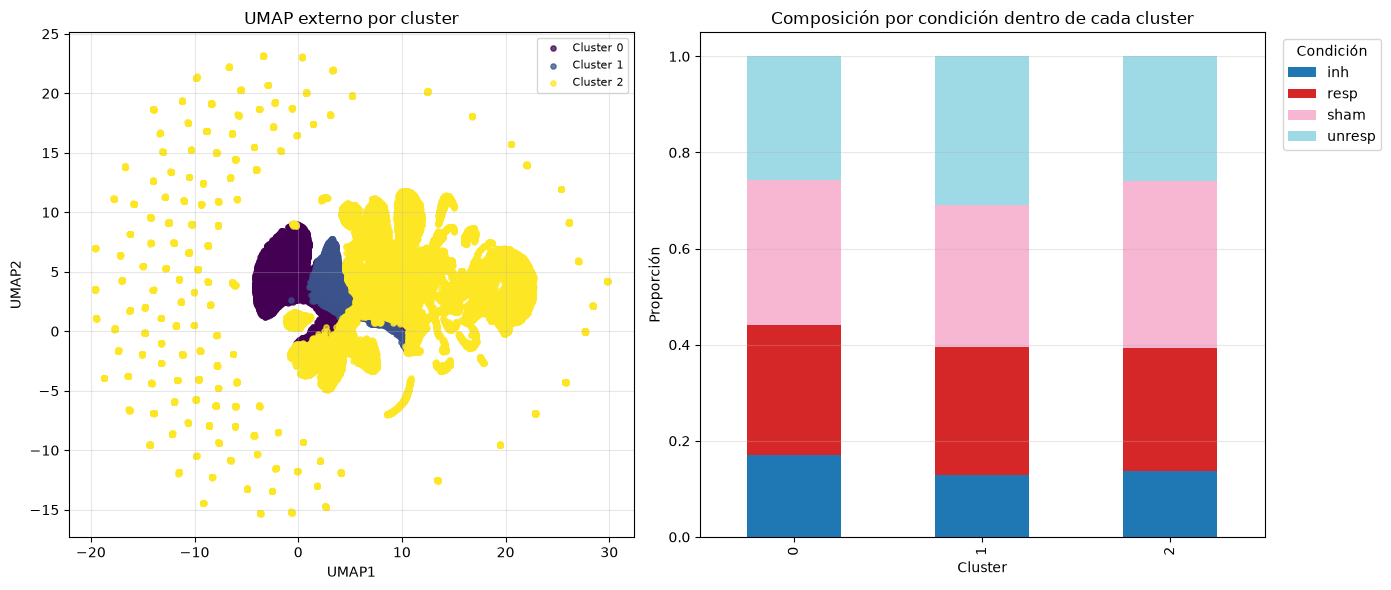


Figura guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_comparison.png

Comparación cualitativa con el análisis interno:
- Cluster 0: actividad moderada / señal más estable | n=38023, eventos=17.95, amplitud media=0.6243
- Cluster 1: eventos frecuentes y sostenidos | n=13048, eventos=11.37, amplitud media=1.9407
- Cluster 2: actividad moderada / señal más estable | n=143969, eventos=2.99, amplitud media=0.4426


In [8]:
# Construcción del dataset estándar de características por ROI y día
manifest_records = manifest.to_dict(orient='records')
feature_rows = []
missing_files = []
standard_example_saved = False
processed_files = 0
total_rois_seen = 0
total_rois_sampled = 0
max_rois_per_file = 80
rng = np.random.default_rng(42)

for row in manifest_records:
    days = row['available_days_list']
    for day_token in days:
        mat_path = resolve_sample_path(row, day_token)
        if not mat_path.exists():
            missing_files.append(str(mat_path))
            continue

        sample = load_external_mat(mat_path)
        activity = sample['activity_dff']
        meta = sample['meta']
        roi_x = np.asarray(meta.get('roi_x', []), dtype=float).reshape(-1)
        roi_y = np.asarray(meta.get('roi_y', []), dtype=float).reshape(-1)

        # Asegurar orientación frames x ROIs
        if activity.shape[0] == len(roi_x) and activity.shape[1] != len(roi_x):
            activity = activity.T
        elif activity.shape[1] != len(roi_x) and activity.shape[0] < activity.shape[1]:
            activity = activity.T

        n_frames, n_rois = activity.shape
        if len(roi_x) != n_rois:
            roi_x = np.full(n_rois, np.nan)
        if len(roi_y) != n_rois:
            roi_y = np.full(n_rois, np.nan)

        total_rois_seen += int(n_rois)
        processed_files += 1
        if processed_files <= 3 or processed_files % 10 == 0:
            print(f'Procesando {processed_files}: {mat_path.name} -> {n_frames} frames, {n_rois} ROIs')

        if not standard_example_saved:
            standard_preview_path = OUTPUT_DIR / 'sample_standard_wide.csv'
            standard_preview = to_standard_wide(activity)
            standard_preview.to_csv(standard_preview_path, index=False)
            print('\nVista estándar guardada en:', standard_preview_path)
            standard_example_saved = True

        if n_rois > max_rois_per_file:
            roi_indices = np.sort(rng.choice(n_rois, size=max_rois_per_file, replace=False))
        else:
            roi_indices = np.arange(n_rois)
        total_rois_sampled += int(len(roi_indices))

        for roi_idx in roi_indices:
            trace = activity[:, roi_idx]
            feats = extract_trace_features(trace)
            feature_rows.append({
                'condition': row['condition'],
                'mouse': row['mouse'],
                'FOV': row['FOV'],
                'day': day_token,
                'sample_id': f"{row['condition']}_{row['mouse']}_{row['FOV']}_{day_token}",
                'source_file': mat_path.name,
                'roi_index': roi_idx + 1,
                'roi_label': f'ROI{roi_idx + 1}',
                'roi_x': float(roi_x[roi_idx]) if np.isfinite(roi_x[roi_idx]) else np.nan,
                'roi_y': float(roi_y[roi_idx]) if np.isfinite(roi_y[roi_idx]) else np.nan,
                'n_frames': int(n_frames),
                **feats,
            })

external_features = pd.DataFrame(feature_rows)
print('\nROIs totales observadas:', total_rois_seen)
print('ROIs muestreadas para el análisis:', total_rois_sampled)
print('Dimensión del dataset de características externas:', external_features.shape)
print(external_features.head().to_string(index=False))

features_csv = OUTPUT_DIR / 'external_roi_day_features_sampled.csv.gz'
external_features.to_csv(features_csv, index=False, compression='gzip')
print('\nArchivo completo exportado en formato comprimido:')
print(features_csv)
if len(external_features) <= 200000:
    features_xlsx = OUTPUT_DIR / 'external_roi_day_features.xlsx'
    external_features.to_excel(features_xlsx, index=False)
    print(features_xlsx)
else:
    print('Se omite Excel completo porque el dataset supera 200000 filas.')

if missing_files:
    missing_path = OUTPUT_DIR / 'missing_external_files.txt'
    missing_path.write_text('\n'.join(missing_files), encoding='utf-8')
    print(f'Archivos faltantes: {len(missing_files)}. Lista guardada en {missing_path}')
else:
    print('No se detectaron archivos faltantes.')

# Clustering comparativo con el mismo espíritu del pipeline interno
numeric_features = [
    'mean_signal',
    'std_signal',
    'min_signal',
    'max_signal',
    'baseline_center',
    'threshold',
    'n_events',
    'mean_event_duration',
    'max_event_duration',
    'mean_event_amplitude',
    'max_event_amplitude',
    'auc_above_baseline',
    'peak_value',
    'global_slope',
]

X = external_features[numeric_features].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

eval_size = min(50000, len(external_features))
eval_idx = external_features.sample(n=eval_size, random_state=42).index if len(external_features) > eval_size else external_features.index
X_eval = X_scaled[eval_idx]
print(f'\nEvaluación interna con muestra de {len(eval_idx)} filas para evitar problemas de memoria.')

silhouette_rows = []
max_k = min(6, len(external_features) - 1)
for k in range(2, max_k + 1):
    trial = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=8192)
    labels = trial.fit_predict(X_eval)
    silhouette_rows.append({'k': k, 'silhouette': float(silhouette_score(X_eval, labels))})

silhouette_df = pd.DataFrame(silhouette_rows)
print('\nSilhouette por k:')
print(silhouette_df.to_string(index=False))

k_final = 3 if len(external_features) >= 3 else 2
kmeans = MiniBatchKMeans(n_clusters=k_final, random_state=42, n_init=10, batch_size=8192)
external_features['Cluster'] = kmeans.fit_predict(X_scaled)

viz_size = min(50000, len(external_features))
viz_idx = external_features.sample(n=viz_size, random_state=42).index if len(external_features) > viz_size else external_features.index
viz_df = external_features.loc[viz_idx].copy()
X_viz = X_scaled[viz_idx]

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_viz)
viz_df['PCA1'] = pca_coords[:, 0]
viz_df['PCA2'] = pca_coords[:, 1]

if umap is not None and len(viz_df) > 20:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.25, n_components=2, random_state=42)
    umap_coords = reducer.fit_transform(X_viz)
    viz_df['UMAP1'] = umap_coords[:, 0]
    viz_df['UMAP2'] = umap_coords[:, 1]
else:
    viz_df['UMAP1'] = viz_df['PCA1']
    viz_df['UMAP2'] = viz_df['PCA2']

cluster_summary = external_features.groupby('Cluster')[numeric_features].mean().round(4).reset_index()
cluster_summary['n_samples'] = external_features.groupby('Cluster').size().values
cluster_summary['event_score'] = cluster_summary['n_events'] + cluster_summary['mean_event_duration']
cluster_summary['amplitude_score'] = cluster_summary['mean_event_amplitude'] + cluster_summary['max_event_amplitude']
cluster_summary['stability_score'] = 1.0 / (cluster_summary['std_signal'] + 1e-9)

# Etiquetas interpretativas comparables con el análisis interno
labels_map = {}
amp_cluster = int(cluster_summary.sort_values(['amplitude_score', 'event_score'], ascending=False).iloc[0]['Cluster'])
evt_cluster = int(cluster_summary.sort_values(['event_score', 'amplitude_score'], ascending=False).iloc[0]['Cluster'])
labels_map[amp_cluster] = 'alta amplitud / posible señal extrema'
labels_map[evt_cluster] = 'eventos frecuentes y sostenidos'
for cluster_id in cluster_summary['Cluster']:
    labels_map.setdefault(int(cluster_id), 'actividad moderada / señal más estable')
cluster_summary['Interpretacion'] = cluster_summary['Cluster'].map(labels_map)

print('\nResumen de clusters externos:')
print(cluster_summary[['Cluster', 'n_samples', 'n_events', 'mean_event_duration', 'max_event_amplitude', 'Interpretacion']].to_string(index=False))

cluster_summary_csv = OUTPUT_DIR / 'external_cluster_summary_sampled.csv'
cluster_summary_xlsx = OUTPUT_DIR / 'external_cluster_summary_sampled.xlsx'
external_clusters_csv = OUTPUT_DIR / 'external_clusters_sampled.csv.gz'
external_viz_csv = OUTPUT_DIR / 'external_clusters_visualization_sample.csv'
cluster_summary.to_csv(cluster_summary_csv, index=False)
cluster_summary.to_excel(cluster_summary_xlsx, index=False)
external_features.to_csv(external_clusters_csv, index=False, compression='gzip')
viz_df.to_csv(external_viz_csv, index=False)
print('\nArchivos exportados:')
print(cluster_summary_csv)
print(cluster_summary_xlsx)
print(external_clusters_csv)
print(external_viz_csv)

# Comparación visual: UMAP y composición por condición
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cluster_palette = {0: '#440154', 1: '#3b528b', 2: '#fde725'}
for cluster_id, color in cluster_palette.items():
    subset = viz_df[viz_df['Cluster'] == cluster_id]
    if subset.empty:
        continue
    axes[0].scatter(subset['UMAP1'], subset['UMAP2'], s=14, alpha=0.75, c=color, label=f'Cluster {cluster_id}')
axes[0].set_title('UMAP externo por cluster')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

condition_order = external_features['condition'].dropna().unique().tolist()
condition_cluster = pd.crosstab(external_features['Cluster'], external_features['condition'], normalize='index').reindex(columns=condition_order, fill_value=0)
condition_cluster.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Composición por condición dentro de cada cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Condición', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / 'external_clusters_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('\nFigura guardada en:', plot_path)

# Resumen breve para comparar con el pipeline interno
print('\nComparación cualitativa con el análisis interno:')
for row in cluster_summary[['Cluster', 'Interpretacion', 'n_samples', 'n_events', 'mean_event_amplitude']].itertuples(index=False):
    print(f'- Cluster {row.Cluster}: {row.Interpretacion} | n={row.n_samples}, eventos={row.n_events:.2f}, amplitud media={row.mean_event_amplitude:.4f}')


Procesando 1: data_d1.mat -> 2088 frames, 382 ROIs
Vista estándar guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\sample_standard_wide.csv
Procesando 2: data_d11.mat -> 2088 frames, 382 ROIs
Procesando 3: data_d15.mat -> 2088 frames, 382 ROIs
Procesando 25: data_d1.mat -> 2088 frames, 350 ROIs
Procesando 50: data_d11.mat -> 2088 frames, 287 ROIs
Procesando 75: data_d15.mat -> 2088 frames, 419 ROIs
Procesando 100: data_d23.mat -> 2088 frames, 395 ROIs
Procesando 125: data_d3.mat -> 2088 frames, 459 ROIs
Procesando 150: data_d5.mat -> 2088 frames, 405 ROIs
Procesando 175: data_d7.mat -> 2088 frames, 329 ROIs
Procesando 200: data_d9.mat -> 2088 frames, 409 ROIs
Procesando 225: data_d1.mat -> 2088 frames, 428 ROIs
Procesando 250: data_d11.mat -> 2088 frames, 389 ROIs
Procesando 275: data_d15.mat -> 2088 frames, 419 ROIs
Procesando 300: data_d23.mat -> 2088 frames, 455 ROIs
Procesando 325: data_d5.mat -> 2088 frames, 439 ROIs
Procesando 350: data

c:\Users\cabs2\Documents\Proyecto IA\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Resumen de clusters externos:
 Cluster  n_samples  n_events  mean_event_duration  max_event_amplitude                         Interpretacion
       0      22967    3.5870               6.8546               0.5769 actividad moderada / señal más estable
       1       6531   17.7368              12.1256               2.0139        eventos frecuentes y sostenidos
       2       1642    4.0755               8.5536              14.5149  alta amplitud / posible señal extrema

Archivos exportados:
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_cluster_summary_balanced.csv
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_cluster_summary_balanced.xlsx
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_balanced.csv.gz
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_visualization_balanced.csv


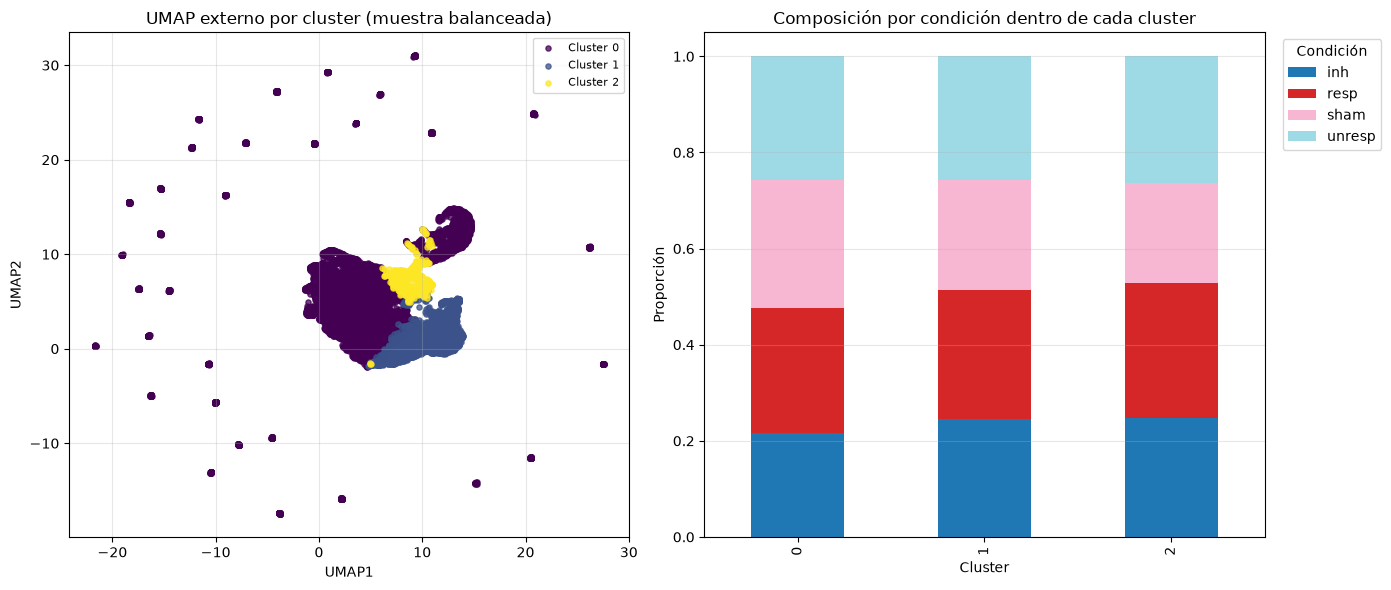


Figura guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\external_clusters_comparison_balanced.png

Comparación cualitativa con el análisis interno:
- Cluster 0: actividad moderada / señal más estable | n=22967, eventos=3.59, amplitud media=0.3534
- Cluster 1: eventos frecuentes y sostenidos | n=6531, eventos=17.74, amplitud media=0.6500
- Cluster 2: alta amplitud / posible señal extrema | n=1642, eventos=4.08, amplitud media=3.4153


In [10]:
# Construcción del dataset estándar de características por ROI y día (optimizado para velocidad)
manifest_records = manifest.to_dict(orient='records')
feature_rows = []
missing_files = []
standard_example_saved = False
processed_files = 0
total_rois_seen = 0
total_rois_sampled = 0

# Preset recomendado para acelerar
max_rois_per_file = 20                # muestreo inicial por archivo
n_per_condition_day = 1000            # tope final balanceado por condición y día
silhouette_sample_size = 5000         # submuestra para elegir k
viz_size = 10000                      # submuestra para PCA/UMAP
rng = np.random.default_rng(42)

for row in manifest_records:
    days = row['available_days_list']
    for day_token in days:
        mat_path = resolve_sample_path(row, day_token)
        if not mat_path.exists():
            missing_files.append(str(mat_path))
            continue

        sample = load_external_mat(mat_path)
        activity = sample['activity_dff']
        meta = sample['meta']
        roi_x = np.asarray(meta.get('roi_x', []), dtype=float).reshape(-1)
        roi_y = np.asarray(meta.get('roi_y', []), dtype=float).reshape(-1)

        # Asegurar orientación frames x ROIs
        if activity.shape[0] == len(roi_x) and activity.shape[1] != len(roi_x):
            activity = activity.T
        elif activity.shape[1] != len(roi_x) and activity.shape[0] < activity.shape[1]:
            activity = activity.T

        n_frames, n_rois = activity.shape
        if len(roi_x) != n_rois:
            roi_x = np.full(n_rois, np.nan)
        if len(roi_y) != n_rois:
            roi_y = np.full(n_rois, np.nan)

        total_rois_seen += int(n_rois)
        processed_files += 1
        if processed_files <= 3 or processed_files % 25 == 0:
            print(f'Procesando {processed_files}: {mat_path.name} -> {n_frames} frames, {n_rois} ROIs')

        if not standard_example_saved:
            standard_preview_path = OUTPUT_DIR / 'sample_standard_wide.csv'
            to_standard_wide(activity).to_csv(standard_preview_path, index=False)
            print('Vista estándar guardada en:', standard_preview_path)
            standard_example_saved = True

        # Muestreo inicial ligero por archivo
        if n_rois > max_rois_per_file:
            roi_indices = np.sort(rng.choice(n_rois, size=max_rois_per_file, replace=False))
        else:
            roi_indices = np.arange(n_rois)
        total_rois_sampled += int(len(roi_indices))

        for roi_idx in roi_indices:
            trace = activity[:, roi_idx]
            feats = extract_trace_features(trace)
            feature_rows.append({
                'condition': row['condition'],
                'mouse': row['mouse'],
                'FOV': row['FOV'],
                'day': day_token,
                'sample_id': f"{row['condition']}_{row['mouse']}_{row['FOV']}_{day_token}",
                'source_file': mat_path.name,
                'roi_index': roi_idx + 1,
                'roi_label': f'ROI{roi_idx + 1}',
                'roi_x': float(roi_x[roi_idx]) if np.isfinite(roi_x[roi_idx]) else np.nan,
                'roi_y': float(roi_y[roi_idx]) if np.isfinite(roi_y[roi_idx]) else np.nan,
                'n_frames': int(n_frames),
                **feats,
            })

external_features_raw = pd.DataFrame(feature_rows)
print('\nROIs totales observadas:', total_rois_seen)
print('ROIs muestreadas por archivo (etapa 1):', total_rois_sampled)
print('Tamaño antes del balance final:', external_features_raw.shape)

# Balance final por condición y día
balanced_parts = []
for (_, _), group_df in external_features_raw.groupby(['condition', 'day'], sort=True):
    n_take = min(len(group_df), n_per_condition_day)
    balanced_parts.append(group_df.sample(n=n_take, random_state=42))

external_features = pd.concat(balanced_parts, ignore_index=True)
print('Tamaño final tras balance por condición-día:', external_features.shape)
print('\nConteo por condición y día (post-balance):')
print(
    external_features
    .groupby(['condition', 'day'])
    .size()
    .rename('n_rois')
    .reset_index()
    .sort_values(['condition', 'day'])
    .to_string(index=False)
 )

print('\nVista rápida del dataset ROI-día final:')
print(external_features.head().to_string(index=False))

features_csv = OUTPUT_DIR / 'external_roi_day_features_balanced.csv.gz'
external_features.to_csv(features_csv, index=False, compression='gzip')
print('\nArchivo balanceado exportado (comprimido):')
print(features_csv)

if len(external_features) <= 200000:
    features_xlsx = OUTPUT_DIR / 'external_roi_day_features_balanced.xlsx'
    external_features.to_excel(features_xlsx, index=False)
    print(features_xlsx)
else:
    print('Se omite Excel porque el dataset supera 200000 filas.')

if missing_files:
    missing_path = OUTPUT_DIR / 'missing_external_files.txt'
    missing_path.write_text('\n'.join(missing_files), encoding='utf-8')
    print(f'Archivos faltantes: {len(missing_files)}. Lista guardada en {missing_path}')
else:
    print('No se detectaron archivos faltantes.')

# Clustering comparativo con el mismo espíritu del pipeline interno
numeric_features = [
    'mean_signal',
    'std_signal',
    'min_signal',
    'max_signal',
    'baseline_center',
    'threshold',
    'n_events',
    'mean_event_duration',
    'max_event_duration',
    'mean_event_amplitude',
    'max_event_amplitude',
    'auc_above_baseline',
    'peak_value',
    'global_slope',
]

if len(external_features) < 3:
    raise ValueError('El dataset balanceado es demasiado pequeño para clustering (requiere al menos 3 filas).')

X = external_features[numeric_features].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# Evaluación de k solo en submuestra chica para acelerar
eval_size = min(silhouette_sample_size, len(external_features))
eval_idx = external_features.sample(n=eval_size, random_state=42).index if len(external_features) > eval_size else external_features.index
X_eval = X_scaled[eval_idx]
print(f'\nEvaluación de silhouette con {len(eval_idx)} filas.')

silhouette_rows = []
max_k = min(6, len(X_eval) - 1)
for k in range(2, max_k + 1):
    trial = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=4096)
    labels = trial.fit_predict(X_eval)
    silhouette_rows.append({'k': k, 'silhouette': float(silhouette_score(X_eval, labels))})

silhouette_df = pd.DataFrame(silhouette_rows)
print('\nSilhouette por k:')
print(silhouette_df.to_string(index=False))

k_final = 3 if len(external_features) >= 3 else 2
kmeans = MiniBatchKMeans(n_clusters=k_final, random_state=42, n_init=10, batch_size=4096)
external_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Submuestra para visualización
viz_size_eff = min(viz_size, len(external_features))
viz_idx = external_features.sample(n=viz_size_eff, random_state=42).index if len(external_features) > viz_size_eff else external_features.index
viz_df = external_features.loc[viz_idx].copy()
X_viz = X_scaled[viz_idx]

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_viz)
viz_df['PCA1'] = pca_coords[:, 0]
viz_df['PCA2'] = pca_coords[:, 1]

if umap is not None and len(viz_df) > 20:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.25, n_components=2, random_state=42)
    umap_coords = reducer.fit_transform(X_viz)
    viz_df['UMAP1'] = umap_coords[:, 0]
    viz_df['UMAP2'] = umap_coords[:, 1]
else:
    viz_df['UMAP1'] = viz_df['PCA1']
    viz_df['UMAP2'] = viz_df['PCA2']

cluster_summary = external_features.groupby('Cluster')[numeric_features].mean().round(4).reset_index()
cluster_summary['n_samples'] = external_features.groupby('Cluster').size().values
cluster_summary['event_score'] = cluster_summary['n_events'] + cluster_summary['mean_event_duration']
cluster_summary['amplitude_score'] = cluster_summary['mean_event_amplitude'] + cluster_summary['max_event_amplitude']
cluster_summary['stability_score'] = 1.0 / (cluster_summary['std_signal'] + 1e-9)

# Etiquetas interpretativas comparables con el análisis interno
labels_map = {}
amp_cluster = int(cluster_summary.sort_values(['amplitude_score', 'event_score'], ascending=False).iloc[0]['Cluster'])
evt_cluster = int(cluster_summary.sort_values(['event_score', 'amplitude_score'], ascending=False).iloc[0]['Cluster'])
labels_map[amp_cluster] = 'alta amplitud / posible señal extrema'
labels_map[evt_cluster] = 'eventos frecuentes y sostenidos'
for cluster_id in cluster_summary['Cluster']:
    labels_map.setdefault(int(cluster_id), 'actividad moderada / señal más estable')
cluster_summary['Interpretacion'] = cluster_summary['Cluster'].map(labels_map)

print('\nResumen de clusters externos:')
print(cluster_summary[['Cluster', 'n_samples', 'n_events', 'mean_event_duration', 'max_event_amplitude', 'Interpretacion']].to_string(index=False))

cluster_summary_csv = OUTPUT_DIR / 'external_cluster_summary_balanced.csv'
cluster_summary_xlsx = OUTPUT_DIR / 'external_cluster_summary_balanced.xlsx'
external_clusters_csv = OUTPUT_DIR / 'external_clusters_balanced.csv.gz'
external_viz_csv = OUTPUT_DIR / 'external_clusters_visualization_balanced.csv'
cluster_summary.to_csv(cluster_summary_csv, index=False)
cluster_summary.to_excel(cluster_summary_xlsx, index=False)
external_features.to_csv(external_clusters_csv, index=False, compression='gzip')
viz_df.to_csv(external_viz_csv, index=False)
print('\nArchivos exportados:')
print(cluster_summary_csv)
print(cluster_summary_xlsx)
print(external_clusters_csv)
print(external_viz_csv)

# Comparación visual: UMAP y composición por condición
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cluster_palette = {0: '#440154', 1: '#3b528b', 2: '#fde725'}
for cluster_id, color in cluster_palette.items():
    subset = viz_df[viz_df['Cluster'] == cluster_id]
    if subset.empty:
        continue
    axes[0].scatter(subset['UMAP1'], subset['UMAP2'], s=14, alpha=0.75, c=color, label=f'Cluster {cluster_id}')
axes[0].set_title('UMAP externo por cluster (muestra balanceada)')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

condition_order = external_features['condition'].dropna().unique().tolist()
condition_cluster = pd.crosstab(
    external_features['Cluster'],
    external_features['condition'],
    normalize='index'
 ).reindex(columns=condition_order, fill_value=0)
condition_cluster.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Composición por condición dentro de cada cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Condición', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / 'external_clusters_comparison_balanced.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('\nFigura guardada en:', plot_path)

# Resumen breve para comparar con el pipeline interno
print('\nComparación cualitativa con el análisis interno:')
for row in cluster_summary[['Cluster', 'Interpretacion', 'n_samples', 'n_events', 'mean_event_amplitude']].itertuples(index=False):
    print(f'- Cluster {row.Cluster}: {row.Interpretacion} | n={row.n_samples}, eventos={row.n_events:.2f}, amplitud media={row.mean_event_amplitude:.4f}')

In [12]:
# Consolidación final ROI-día y tablas para comparación con el proyecto principal

if 'external_features' not in globals():
    raise ValueError('No existe external_features en memoria. Ejecuta primero la celda 6.')

# 1) Dataset estándar recomendado (una fila = ROI en un día/sesión)
dataset_estandar = external_features.copy()
dataset_estandar['ROI'] = dataset_estandar['roi_label']
dataset_estandar['mean_basal'] = dataset_estandar['baseline_center']
dataset_estandar['std_basal'] = dataset_estandar['std_signal']
dataset_estandar['cluster'] = dataset_estandar['Cluster']

columnas_estandar = [
    'mouse',
    'FOV',
    'day',
    'condition',
    'ROI',
    'n_frames',
    'n_events',
    'mean_event_duration',
    'max_event_amplitude',
    'mean_basal',
    'std_basal',
    'cluster',
]

dataset_estandar = dataset_estandar[columnas_estandar].copy()

# Verificación y limpieza de unidad ROI-día
dup_mask = dataset_estandar.duplicated(subset=['mouse', 'FOV', 'day', 'ROI'], keep='first')
dup_count = int(dup_mask.sum())
if dup_count > 0:
    print(f'Duplicados ROI-día detectados: {dup_count}. Se conservará la primera ocurrencia por ROI-día.')
    dataset_estandar = dataset_estandar.loc[~dup_mask].reset_index(drop=True)
else:
    print('Duplicados ROI-día detectados: 0')

print('Dimensión dataset estándar ROI-día:', dataset_estandar.shape)
print(dataset_estandar.head().to_string(index=False))

# Exportar dataset estándar
dataset_estandar_csv = OUTPUT_DIR / 'external_dataset_estandar_roi_dia.csv.gz'
dataset_estandar_xlsx = OUTPUT_DIR / 'external_dataset_estandar_roi_dia.xlsx'
dataset_estandar.to_csv(dataset_estandar_csv, index=False, compression='gzip')
dataset_estandar.to_excel(dataset_estandar_xlsx, index=False)

print('\nDataset estándar exportado:')
print(dataset_estandar_csv)
print(dataset_estandar_xlsx)

# 2) Resumen por cluster externo
resumen_cluster_externo = (
    dataset_estandar
    .groupby('cluster', as_index=False)
    .agg(
        n_ROIs_dia=('ROI', 'size'),
        n_events=('n_events', 'mean'),
        duration=('mean_event_duration', 'mean'),
        amplitude=('max_event_amplitude', 'mean'),
        std_basal=('std_basal', 'mean'),
    )
    .sort_values('cluster')
)

resumen_cluster_externo[['n_events', 'duration', 'amplitude', 'std_basal']] = (
    resumen_cluster_externo[['n_events', 'duration', 'amplitude', 'std_basal']].round(4)
)

print('\nResumen por cluster externo (ROI-día):')
print(resumen_cluster_externo.to_string(index=False))

resumen_cluster_csv = OUTPUT_DIR / 'external_resumen_cluster_roi_dia.csv'
resumen_cluster_xlsx = OUTPUT_DIR / 'external_resumen_cluster_roi_dia.xlsx'
resumen_cluster_externo.to_csv(resumen_cluster_csv, index=False)
resumen_cluster_externo.to_excel(resumen_cluster_xlsx, index=False)

# 3) Composición por condición
composicion_condicion_count = pd.crosstab(dataset_estandar['cluster'], dataset_estandar['condition'])
composicion_condicion_prop = pd.crosstab(
    dataset_estandar['cluster'],
    dataset_estandar['condition'],
    normalize='index',
)

print('\nComposición por condición (conteos):')
print(composicion_condicion_count.to_string())
print('\nComposición por condición (proporciones):')
print(composicion_condicion_prop.round(4).to_string())

comp_count_csv = OUTPUT_DIR / 'external_composicion_condicion_conteos.csv'
comp_prop_csv = OUTPUT_DIR / 'external_composicion_condicion_proporciones.csv'
composicion_condicion_count.to_csv(comp_count_csv)
composicion_condicion_prop.round(6).to_csv(comp_prop_csv)

# 4) Tabla comparativa con datos principales (sin mezclar datasets)
tabla_comparativa = pd.DataFrame([
    {
        'Análisis': 'Unidad de análisis',
        'Datos propios': 'ROI',
        'Datos externos': 'ROI-día',
    },
    {
        'Análisis': 'Indicador',
        'Datos propios': 'GCaMP/jRGECO/GCaMP6',
        'Datos externos': 'GCaMP6m',
    },
    {
        'Análisis': 'Método IA',
        'Datos propios': 'ΔF/F0 + eventos pre-peak; UMAP + K-means',
        'Datos externos': 'Características ROI-día; UMAP + K-means',
    },
    {
        'Análisis': 'Resultado',
        'Datos propios': '3 patrones pre-peak',
        'Datos externos': '3 patrones pre-peak (externo)',
    },
])

print('\nTabla comparativa (propios vs externos):')
print(tabla_comparativa.to_string(index=False))

tabla_comp_csv = OUTPUT_DIR / 'tabla_comparativa_propios_vs_externos.csv'
tabla_comp_xlsx = OUTPUT_DIR / 'tabla_comparativa_propios_vs_externos.xlsx'
tabla_comparativa.to_csv(tabla_comp_csv, index=False)
tabla_comparativa.to_excel(tabla_comp_xlsx, index=False)

print('\nArchivos de esta sección:')
print(resumen_cluster_csv)
print(resumen_cluster_xlsx)
print(comp_count_csv)
print(comp_prop_csv)
print(tabla_comp_csv)
print(tabla_comp_xlsx)

Duplicados ROI-día detectados: 93. Se conservará la primera ocurrencia por ROI-día.
Dimensión dataset estándar ROI-día: (31047, 12)
mouse        FOV day condition    ROI  n_frames  n_events  mean_event_duration  max_event_amplitude  mean_basal  std_basal  cluster
 U872 Reg01_z166  d1       inh ROI379      2088         0                  NaN                  NaN         NaN        NaN        0
 U480 Reg01_z154  d1       inh ROI387      2088         5                8.200             0.136007    0.068615   0.053067        0
 U413 Reg03_z182  d1       inh ROI177      2088         0                  NaN                  NaN         NaN        NaN        0
 U872 Reg01_z234  d1       inh ROI303      2088        10                7.300             1.002772    0.153781   0.094486        0
 U872 Reg01_z303  d1       inh  ROI86      2088         8                8.375             1.261085    0.148867   0.114130        0

Dataset estándar exportado:
c:\Users\cabs2\Documents\Proyecto IA\Analisis_R

In [13]:
import pandas as pd

tabla_resumen_externa = pd.DataFrame([
    {
        "Cluster externo": "Cluster 0",
        "n muestras": 22967,
        "Eventos promedio": 3.59,
        "Duración promedio": 6.85,
        "Amplitud promedio": 0.35,
        "Amplitud máxima": 0.58,
        "Interpretación corregida": "Actividad basal/pre-peak moderada y relativamente estable"
    },
    {
        "Cluster externo": "Cluster 1",
        "n muestras": 6531,
        "Eventos promedio": 17.74,
        "Duración promedio": 12.13,
        "Amplitud promedio": 0.65,
        "Amplitud máxima": 2.01,
        "Interpretación corregida": "Actividad pre-peak frecuente y sostenida"
    },
    {
        "Cluster externo": "Cluster 2",
        "n muestras": 1642,
        "Eventos promedio": 4.08,
        "Duración promedio": 8.55,
        "Amplitud promedio": 3.42,
        "Amplitud máxima": 14.51,
        "Interpretación corregida": "Alta amplitud o posibles señales extremas/atípicas"
    }
])

ruta_tabla_corregida = OUTPUT_DIR / "tabla_resumen_externa_corregida.xlsx"
tabla_resumen_externa.to_excel(ruta_tabla_corregida, index=False)

print("Tabla corregida guardada en:", ruta_tabla_corregida)
display(tabla_resumen_externa)

Tabla corregida guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\tabla_resumen_externa_corregida.xlsx


,Cluster externo,n muestras,Eventos promedio,Duración promedio,Amplitud promedio,Amplitud máxima,Interpretación corregida
0,Cluster 0,22967,3.59,6.85,0.35,0.58,Actividad basal/pre-peak moderada y relativame...
1,Cluster 1,6531,17.74,12.13,0.65,2.01,Actividad pre-peak frecuente y sostenida
2,Cluster 2,1642,4.08,8.55,3.42,14.51,Alta amplitud o posibles señales extremas/atíp...


In [16]:
import pandas as pd

tabla_comparativa = pd.DataFrame([
    {
        "Aspecto": "Rol en el proyecto",
        "Datos propios": "Análisis principal",
        "Dataset externo": "Validación exploratoria del pipeline"
    },
    {
        "Aspecto": "Origen de los datos",
        "Datos propios": "Archivos entregados por el profesor",
        "Dataset externo": "Dataset público de poblaciones neuronales en corteza auditiva de ratón"
    },
    {
        "Aspecto": "Tipo de señal",
        "Datos propios": "Principalmente fluorescencia de calcio asociada a GCaMP, GCaMP6 y/o jRGECO1a",
        "Dataset externo": "Señal GCaMP6m preprocesada"
    },
    {
        "Aspecto": "Unidad de análisis",
        "Datos propios": "ROI celular",
        "Dataset externo": "ROI/día o muestra estandarizada"
    },
    {
        "Aspecto": "Obtención de ROIs",
        "Datos propios": "Selección manual en Fiji/ImageJ",
        "Dataset externo": "ROIs ya extraídas y preprocesadas por el dataset"
    },
    {
        "Aspecto": "Preprocesamiento inicial",
        "Datos propios": "Apertura en Fiji, selección de ROIs, exportación de intensidad media",
        "Dataset externo": "Lectura de señales preprocesadas y adaptación al formato estándar"
    },
    {
        "Aspecto": "Normalización",
        "Datos propios": "ΔF/F₀ con F₀ definido como baseline inicial",
        "Dataset externo": "Señales ya preprocesadas; se extrajeron características compatibles con el pipeline"
    },
    {
        "Aspecto": "Escala temporal",
        "Datos propios": "Frames, sin intervalo temporal real confiable",
        "Dataset externo": "Frames/días según metadatos del dataset externo"
    },
    {
        "Aspecto": "Variables extraídas",
        "Datos propios": "Número de eventos pre-peak, duración, amplitud, std basal, umbral, peak",
        "Dataset externo": "Media de señal, std, eventos, duración, amplitud, AUC, peak, score de eventos"
    },
    {
        "Aspecto": "IA aplicada",
        "Datos propios": "UMAP + K-means",
        "Dataset externo": "UMAP + K-means"
    },
    {
        "Aspecto": "Número de clusters",
        "Datos propios": "3",
        "Dataset externo": "3"
    },
    {
        "Aspecto": "Resultado principal",
        "Datos propios": "Se identificaron patrones pre-peak diferenciados entre ROIs",
        "Dataset externo": "Se observaron patrones similares de agrupamiento en datos externos"
    },
    {
        "Aspecto": "Interpretación de clusters",
        "Datos propios": "Actividad frecuente de baja amplitud; eventos intensos; actividad leve/moderada predominante",
        "Dataset externo": "Actividad moderada/estable; eventos frecuentes sostenidos; señales de alta amplitud o extremas"
    },
    {
        "Aspecto": "Uso en la conclusión",
        "Datos propios": "Demuestra que la actividad pre-peak de los datos propios es cuantificable y agrupable",
        "Dataset externo": "Sugiere que el pipeline puede generalizarse a otro conjunto de señales de calcio"
    },
    {
        "Aspecto": "Limitación principal",
        "Datos propios": "Pocos archivos y ausencia de frame interval real",
        "Dataset externo": "Dataset de contexto experimental distinto y señales ya preprocesadas"
    },
    {
        "Aspecto": "Nivel de evidencia",
        "Datos propios": "Principal",
        "Dataset externo": "Complementario/exploratorio"
    },
])

ruta_comparativa = OUTPUT_DIR / "tabla_comparativa_propios_vs_externos_detallada.xlsx"
tabla_comparativa.to_excel(ruta_comparativa, index=False)

print("Tabla comparativa detallada guardada en:", ruta_comparativa)
display(tabla_comparativa)

Tabla comparativa detallada guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\tabla_comparativa_propios_vs_externos_detallada.xlsx


,Aspecto,Datos propios,Dataset externo
0,Rol en el proyecto,Análisis principal,Validación exploratoria del pipeline
1,Origen de los datos,Archivos entregados por el profesor,Dataset público de poblaciones neuronales en c...
2,Tipo de señal,Principalmente fluorescencia de calcio asociad...,Señal GCaMP6m preprocesada
3,Unidad de análisis,ROI celular,ROI/día o muestra estandarizada
4,Obtención de ROIs,Selección manual en Fiji/ImageJ,ROIs ya extraídas y preprocesadas por el dataset
5,Preprocesamiento inicial,"Apertura en Fiji, selección de ROIs, exportaci...",Lectura de señales preprocesadas y adaptación ...
6,Normalización,ΔF/F₀ con F₀ definido como baseline inicial,Señales ya preprocesadas; se extrajeron caract...
7,Escala temporal,"Frames, sin intervalo temporal real confiable",Frames/días según metadatos del dataset externo
8,Variables extraídas,"Número de eventos pre-peak, duración, amplitud...","Media de señal, std, eventos, duración, amplit..."
9,IA aplicada,UMAP + K-means,UMAP + K-means


Tabla de correlaciones externas guardada en: c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\correlacion_peak_vs_basal_externo.xlsx


,Variable basal,Correlación Pearson,Correlación Spearman,Sentido (Spearman),Fuerza (Spearman)
0,max_event_amplitude,0.999995,0.987150,directa,fuerte
1,std_signal,0.977164,0.923995,directa,fuerte
2,mean_event_amplitude,0.781428,0.913545,directa,fuerte
3,mean_event_duration,0.030564,0.601232,directa,moderada
4,threshold,0.121423,0.528768,directa,moderada
5,n_events,0.015939,0.417690,directa,moderada


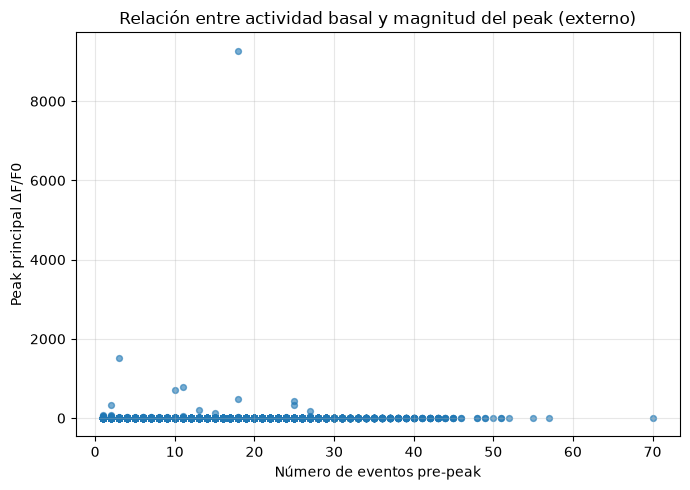

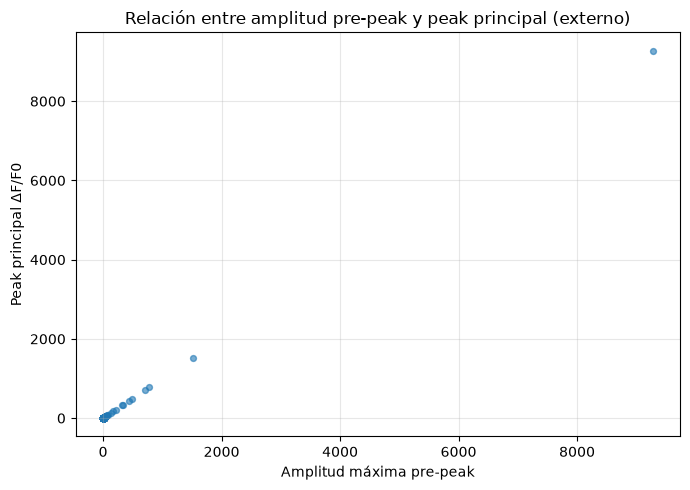


Interpretación rápida (Spearman):
- max_event_amplitude: 0.987 -> relación directa fuerte
- std_signal: 0.924 -> relación directa fuerte
- mean_event_amplitude: 0.914 -> relación directa fuerte
- mean_event_duration: 0.601 -> relación directa moderada
- threshold: 0.529 -> relación directa moderada
- n_events: 0.418 -> relación directa moderada

Gráficos guardados en:
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\scatter_externo_peak_vs_n_events.png
c:\Users\cabs2\Documents\Proyecto IA\Analisis_ROI\análisis_data_externo\salidas\scatter_externo_peak_vs_amplitud_max.png


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'external_features' not in globals():
    raise ValueError('No existe external_features en memoria. Ejecuta primero la celda 6.')

df_corr = external_features.copy()
col_peak = 'peak_value'

features_basal = [
    'n_events',
    'mean_event_duration',
    'mean_event_amplitude',
    'max_event_amplitude',
    'std_signal',
    'threshold',
]

required_cols = [col_peak] + features_basal
missing = [col for col in required_cols if col not in df_corr.columns]
if missing:
    raise ValueError(f'Faltan columnas para el análisis: {missing}')

for col in required_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

df_corr = df_corr[required_cols].replace([np.inf, -np.inf], np.nan).dropna()

if len(df_corr) < 3:
    raise ValueError('No hay suficientes filas válidas para calcular correlaciones en el dataset externo.')

corr_pearson = df_corr.corr(method='pearson')[col_peak].drop(col_peak)
corr_spearman = df_corr.corr(method='spearman')[col_peak].drop(col_peak)

tabla_corr_externa = pd.DataFrame({
    'Variable basal': features_basal,
    'Correlación Pearson': [corr_pearson.get(v, np.nan) for v in features_basal],
    'Correlación Spearman': [corr_spearman.get(v, np.nan) for v in features_basal],
})

def clasificar_fuerza(r):
    if pd.isna(r):
        return 'sin dato'
    valor = abs(r)
    if valor >= 0.7:
        return 'fuerte'
    if valor >= 0.4:
        return 'moderada'
    if valor >= 0.2:
        return 'débil'
    return 'muy débil o nula'

def clasificar_sentido(r):
    if pd.isna(r):
        return 'sin dato'
    if r > 0:
        return 'directa'
    if r < 0:
        return 'inversa'
    return 'nula'

tabla_corr_externa['Sentido (Spearman)'] = tabla_corr_externa['Correlación Spearman'].apply(clasificar_sentido)
tabla_corr_externa['Fuerza (Spearman)'] = tabla_corr_externa['Correlación Spearman'].apply(clasificar_fuerza)
tabla_corr_externa = tabla_corr_externa.sort_values(
    'Correlación Spearman',
    key=lambda s: s.abs(),
    ascending=False
).reset_index(drop=True)

ruta_corr = OUTPUT_DIR / 'correlacion_peak_vs_basal_externo.xlsx'
tabla_corr_externa.to_excel(ruta_corr, index=False)

print('Tabla de correlaciones externas guardada en:', ruta_corr)
display(tabla_corr_externa)

plt.figure(figsize=(7, 5))
plt.scatter(df_corr['n_events'], df_corr[col_peak], alpha=0.6, s=18)
plt.xlabel('Número de eventos pre-peak')
plt.ylabel('Peak principal ΔF/F0')
plt.title('Relación entre actividad basal y magnitud del peak (externo)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
ruta_scatter_eventos = OUTPUT_DIR / 'scatter_externo_peak_vs_n_events.png'
plt.savefig(ruta_scatter_eventos, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df_corr['max_event_amplitude'], df_corr[col_peak], alpha=0.6, s=18)
plt.xlabel('Amplitud máxima pre-peak')
plt.ylabel('Peak principal ΔF/F0')
plt.title('Relación entre amplitud pre-peak y peak principal (externo)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
ruta_scatter_amp = OUTPUT_DIR / 'scatter_externo_peak_vs_amplitud_max.png'
plt.savefig(ruta_scatter_amp, dpi=300, bbox_inches='tight')
plt.show()

print('\nInterpretación rápida (Spearman):')
for _, row in tabla_corr_externa.iterrows():
    print(
        f"- {row['Variable basal']}: "
        f"{row['Correlación Spearman']:.3f} -> "
        f"relación {row['Sentido (Spearman)']} {row['Fuerza (Spearman)']}"
    )

print('\nGráficos guardados en:')
print(ruta_scatter_eventos)
print(ruta_scatter_amp)